# Examen Junio 2024 — Drug dataset (drug200.csv) — Guía paso a paso (práctica + teoría)

**Nombre:** _TU NOMBRE AQUÍ_

Este notebook está estructurado **igual que un examen**:
1) Limpieza y transformaciones (con justificación)  
2) Gráficas tras limpiar  
3) **MLP propio (NumPy)** + accuracy + matriz de confusión (**min 80%**)  
4) **MLPClassifier (sklearn)** (**min 90%**)  
5) **KNN** (**min 87.5%**, aspirar a 90%+)  
6) Comparación KNN vs MLPClassifier (markdown)  
7) Clasificación binaria softDrug vs hardDrug con MLP propio (rendimiento similar o mejor que ej. 3)

> Requisito del enunciado: en el **split** usar `random_state=13`.  
> Dataset: `drug200.csv`.


## 0) Imports + carga del dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

pd.set_option("display.max_columns", 200)


In [3]:
DATA_PATH = "drug200.csv"
df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
df_raw.head()


Shape: (201, 6)


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


### Inspección rápida (tip de examen: tipos + NaNs)

In [4]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          201 non-null    int64  
 1   Sex          201 non-null    object 
 2   BP           201 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      201 non-null    float64
 5   Drug         201 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.6+ KB


In [5]:
df_raw.isna().sum()


Age            0
Sex            0
BP             0
Cholesterol    1
Na_to_K        0
Drug           0
dtype: int64

## Ejercicio 1 (1 punto): Limpieza + transformaciones (justificadas)

**Objetivo:** dejar los datos listos para “cualquier modelo de ML”.

### 1) Qué problemas típicos hay en este dataset
- **1 valor nulo** en `Cholesterol` (según esta versión).
- Inconsistencia de etiquetas en `Drug`: aparece `DrugY` y también `drugA/drugB/drugC/drugX` (mezcla de mayúsculas/minúsculas).

### 2) Decisiones de limpieza (y por qué puntúan)
- **No borrar filas por 1 NaN**: imputamos la categoría más frecuente en `Cholesterol` (categórica).
- **Normalizar etiquetas de `Drug`** (y de categóricas) para evitar que el modelo interprete categorías distintas por culpa de mayúsculas.

> Esto es clave: en examen, “limpiar bien” suele ser detectar estas inconsistencias y corregirlas de forma explícita.


In [6]:
df = df_raw.copy()

# --- 1) Normalizamos texto en categóricas: strip + uppercase donde tenga sentido ---
for col in ["Sex", "BP", "Cholesterol"]:
    df[col] = df[col].astype(str).str.strip().str.upper()
    df.loc[df[col].isin(["NAN", "NONE", ""]), col] = np.nan  # por si viniera como string raro

# --- 2) Normalizamos etiquetas del target Drug para tener SIEMPRE: drugA, drugB, drugC, drugX, drugY ---
def normalize_drug(x):
    x = str(x).strip().lower()
    if x == "druga": return "drugA"
    if x == "drugb": return "drugB"
    if x == "drugc": return "drugC"
    if x == "drugx": return "drugX"
    if x == "drugy": return "drugY"
    return x

df["Drug"] = df["Drug"].apply(normalize_drug)

# Comprobación rápida
print("Clases Drug:", sorted(df['Drug'].unique()))
print("NaNs tras normalizar:", df.isna().sum())
df.head()


Clases Drug: ['drugA', 'drugB', 'drugC', 'drugX', 'drugY']
NaNs tras normalizar: Age            0
Sex            0
BP             0
Cholesterol    1
Na_to_K        0
Drug           0
dtype: int64


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


### 3) Separación X / y

- Features: `Age`, `Sex`, `BP`, `Cholesterol`, `Na_to_K`
- Target: `Drug` (multi-clase)


In [7]:
X = df.drop(columns=["Drug"])
y = df["Drug"]

cat_cols = ["Sex", "BP", "Cholesterol"]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)
print("Distribución de clases:\n", y.value_counts())


Numéricas: ['Age', 'Na_to_K']
Categóricas: ['Sex', 'BP', 'Cholesterol']
Distribución de clases:
 Drug
drugY    91
drugX    55
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


### 4) Pipeline de preprocesado (reutilizable)

**Idea examen:** defines un pipeline y lo reutilizas en todos los modelos.

- Numéricas: imputación mediana + StandardScaler (importante para MLP y KNN)
- Categóricas: imputación moda + OneHotEncoder

`OneHotEncoder(..., sparse_output=False)` para obtener una matriz densa (más cómoda para NumPy).


In [8]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols),
    ],
    remainder="drop"
)

# Split del examen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=13, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (160, 5) Test: (41, 5)


## Ejercicio 2 (1 punto): Representación gráfica (tras limpiar)

Te dejo 4 gráficas típicas:
1) Distribución de clases (bar)  
2) Histograma de edades por clase  
3) Boxplot de `Na_to_K` por clase (suele separar mucho)  
4) Scatter `Na_to_K` vs `Age` (para intuir separabilidad)  


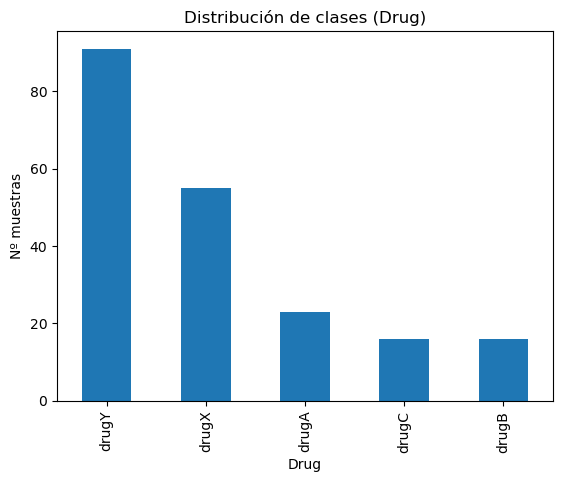

In [9]:
# 1) Distribución de clases
plt.figure()
y.value_counts().plot(kind="bar")
plt.title("Distribución de clases (Drug)")
plt.xlabel("Drug")
plt.ylabel("Nº muestras")
plt.show()


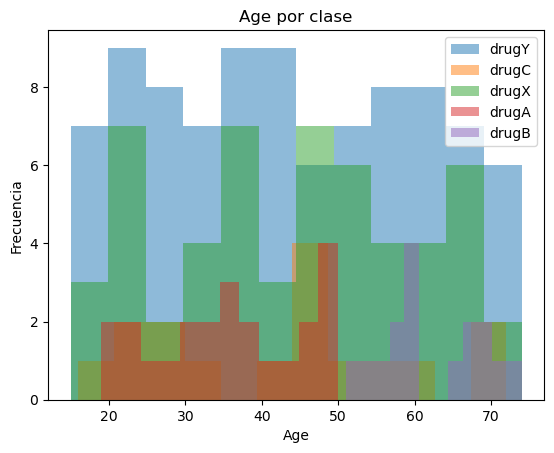

In [10]:
# 2) Histograma de Age por clase
plt.figure()
for cls in y.unique():
    X.loc[y==cls, "Age"].plot(kind="hist", bins=12, alpha=0.5, label=cls)
plt.title("Age por clase")
plt.xlabel("Age")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


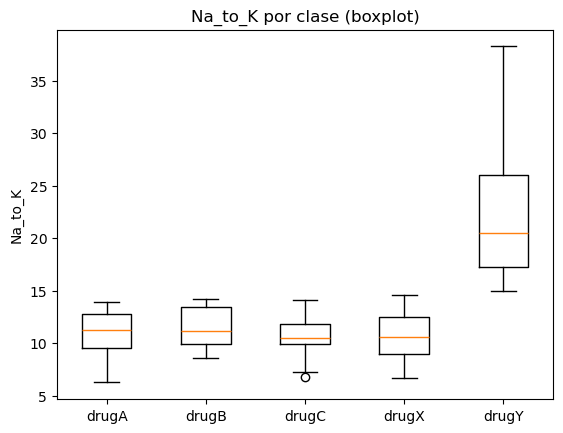

In [12]:
# 3) Boxplot de Na_to_K por clase
plt.figure()
classes = list(sorted(y.unique()))
data = [X.loc[y==cls, "Na_to_K"].dropna() for cls in classes]
plt.boxplot(data, tick_labels=classes)
plt.title("Na_to_K por clase (boxplot)")
plt.ylabel("Na_to_K")
plt.show()


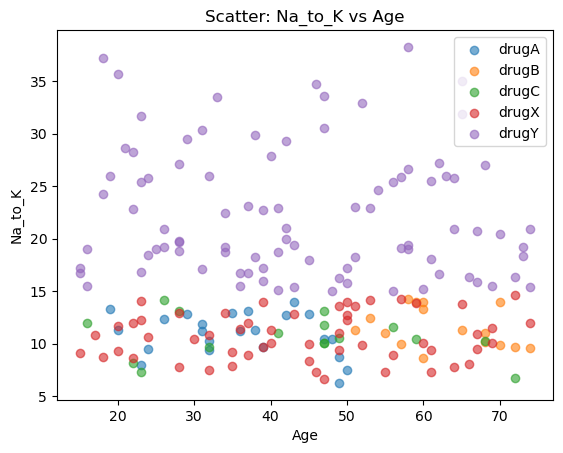

In [13]:
# 4) Scatter Na_to_K vs Age (sin colores fijos: hacemos un plot por clase con alpha)
plt.figure()
for cls in classes:
    plt.scatter(
        X.loc[y==cls, "Age"],
        X.loc[y==cls, "Na_to_K"],
        alpha=0.6,
        label=cls
    )
plt.title("Scatter: Na_to_K vs Age")
plt.xlabel("Age")
plt.ylabel("Na_to_K")
plt.legend()
plt.show()


## Ejercicio 3 (2 puntos): MLP propio (NumPy) — Accuracy >= 80%

**Requisito del examen:**  
- Entrenar con vuestro MLP de prácticas 5/6.  
- Debe haber una prueba con **>1 capa oculta** (aunque no sea el modelo final).  
- Reportar accuracy y matriz de confusión.  

Aquí hacemos MLP multi-clase con:
- Ocultas: ReLU  
- Salida: Softmax  
- Loss: cross-entropy (softmax + CE)  


In [14]:
# Transformación para NumPy (MLP propio)
X_train_t = preprocess.fit_transform(X_train)
X_test_t  = preprocess.transform(X_test)

# Codificamos y a enteros 0..C-1
le = LabelEncoder()
y_train_i = le.fit_transform(y_train)
y_test_i  = le.transform(y_test)

n_classes = len(le.classes_)
print("X_train_t:", X_train_t.shape, " | n_classes:", n_classes, " | classes:", le.classes_)


X_train_t: (160, 9)  | n_classes: 5  | classes: ['drugA' 'drugB' 'drugC' 'drugX' 'drugY']


In [15]:
def one_hot(y_int, k):
    oh = np.zeros((y_int.size, k), dtype=np.float32)
    oh[np.arange(y_int.size), y_int] = 1.0
    return oh

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)

class NumpyMLPMulticlass:
    """MLP multicapa (NumPy) con salida softmax para clasificación multi-clase."""
    def __init__(self, layer_sizes, seed=13, l2=1e-4, activation="relu"):
        self.sizes = list(layer_sizes)
        self.rng = np.random.default_rng(seed)
        self.l2 = float(l2)
        self.activation = activation

        self.W, self.b = [], []
        for i in range(len(self.sizes)-1):
            fan_in, fan_out = self.sizes[i], self.sizes[i+1]
            # He init para ReLU en ocultas
            if i < len(self.sizes)-2 and activation == "relu":
                scale = np.sqrt(2.0 / fan_in)
            else:
                scale = np.sqrt(1.0 / fan_in)
            self.W.append(self.rng.normal(0, scale, size=(fan_in, fan_out)).astype(np.float32))
            self.b.append(np.zeros((1, fan_out), dtype=np.float32))

    def _act(self, z):
        if self.activation == "relu":
            return np.maximum(0, z)
        if self.activation == "tanh":
            return np.tanh(z)
        raise ValueError("activation no soportada")

    def _act_deriv(self, z, a):
        if self.activation == "relu":
            return (z > 0).astype(np.float32)
        if self.activation == "tanh":
            return 1 - a*a
        raise ValueError("activation no soportada")

    def forward(self, X):
        a = X.astype(np.float32)
        activations = [a]
        zs = []
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            zs.append(z)
            if i == len(self.W)-1:
                a = softmax(z)
            else:
                a = self._act(z)
            activations.append(a)
        return activations, zs

    def predict(self, X):
        a = X.astype(np.float32)
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            if i == len(self.W)-1:
                a = softmax(z)
            else:
                a = self._act(z)
        return np.argmax(a, axis=1)

    def fit(self, X, y_int, epochs=800, lr=0.05, batch_size=32, verbose_every=0):
        X = X.astype(np.float32)
        y_oh = one_hot(y_int, self.sizes[-1])
        n = X.shape[0]

        for ep in range(epochs):
            idx = self.rng.permutation(n)
            Xs, Ys = X[idx], y_oh[idx]

            for start in range(0, n, batch_size):
                xb = Xs[start:start+batch_size]
                yb = Ys[start:start+batch_size]

                activations, zs = self.forward(xb)

                # softmax + cross-entropy => delta = out - y
                delta = (activations[-1] - yb) / xb.shape[0]

                dW = [None]*len(self.W)
                db = [None]*len(self.b)

                for i in reversed(range(len(self.W))):
                    a_prev = activations[i]
                    dW[i] = a_prev.T @ delta + self.l2 * self.W[i]
                    db[i] = np.sum(delta, axis=0, keepdims=True)

                    if i > 0:
                        delta = (delta @ self.W[i].T) * self._act_deriv(zs[i-1], activations[i])

                for i in range(len(self.W)):
                    self.W[i] -= lr * dW[i]
                    self.b[i] -= lr * db[i]

            if verbose_every and (ep % verbose_every == 0 or ep == epochs-1):
                acc = (self.predict(X) == y_int).mean()
                print(f"Epoch {ep:4d} | train acc = {acc:.3f}")

        return self


### Prueba 1 (baseline): 1 capa oculta

Sirve para comparar.


Accuracy MLP propio (1 hidden): 0.975609756097561


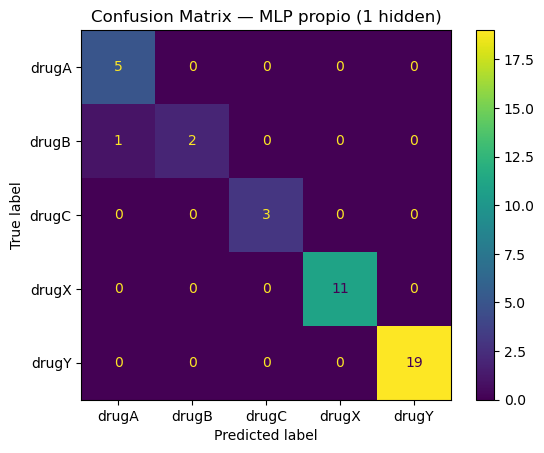

In [16]:
mlp_1h = NumpyMLPMulticlass(
    layer_sizes=[X_train_t.shape[1], 24, n_classes],
    seed=13,
    l2=1e-4,
    activation="relu"
)
mlp_1h.fit(X_train_t, y_train_i, epochs=800, lr=0.05, batch_size=32)

pred_1h = mlp_1h.predict(X_test_t)
acc_1h = accuracy_score(y_test_i, pred_1h)
print("Accuracy MLP propio (1 hidden):", acc_1h)

cm_1h = confusion_matrix(y_test_i, pred_1h)
disp = ConfusionMatrixDisplay(cm_1h, display_labels=le.classes_)
disp.plot(values_format="d")
plt.title("Confusion Matrix — MLP propio (1 hidden)")
plt.show()


### Prueba 2 (requisito): >1 capa oculta

Aquí usamos 2 ocultas: (32, 16).


Accuracy MLP propio (2 hidden): 0.975609756097561


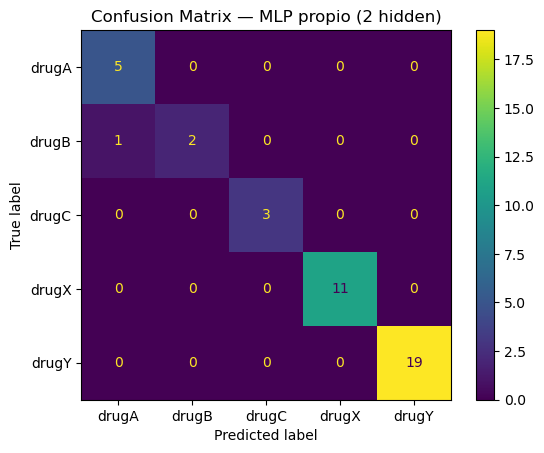

MODELO FINAL (MLP propio): mlp_2h


In [17]:
mlp_2h = NumpyMLPMulticlass(
    layer_sizes=[X_train_t.shape[1], 32, 16, n_classes],
    seed=13,
    l2=1e-4,
    activation="relu"
)
mlp_2h.fit(X_train_t, y_train_i, epochs=800, lr=0.05, batch_size=32)

pred_2h = mlp_2h.predict(X_test_t)
acc_2h = accuracy_score(y_test_i, pred_2h)
print("Accuracy MLP propio (2 hidden):", acc_2h)

cm_2h = confusion_matrix(y_test_i, pred_2h)
disp = ConfusionMatrixDisplay(cm_2h, display_labels=le.classes_)
disp.plot(values_format="d")
plt.title("Confusion Matrix — MLP propio (2 hidden)")
plt.show()

print("MODELO FINAL (MLP propio):", "mlp_2h" if acc_2h >= acc_1h else "mlp_1h")


## Ejercicio 4 (1 punto): MLPClassifier (sklearn) — Accuracy >= 90% (random_state=13)

Para este dataset suele funcionar muy bien `solver="lbfgs"` (converge bien en datasets pequeños).


Accuracy MLPClassifier: 0.975609756097561
              precision    recall  f1-score   support

       drugA      1.000     1.000     1.000         5
       drugB      1.000     0.667     0.800         3
       drugC      1.000     1.000     1.000         3
       drugX      1.000     1.000     1.000        11
       drugY      0.950     1.000     0.974        19

    accuracy                          0.976        41
   macro avg      0.990     0.933     0.955        41
weighted avg      0.977     0.976     0.973        41



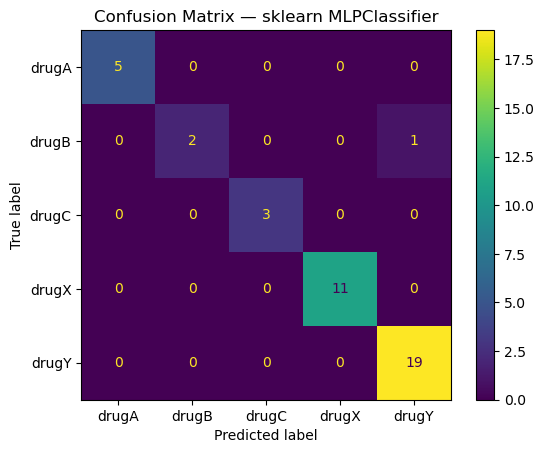

In [18]:
sk_mlp = Pipeline(steps=[
    ("pre", preprocess),
    ("model", MLPClassifier(
        hidden_layer_sizes=(50,),
        solver="lbfgs",
        alpha=1e-4,
        max_iter=2000,
        random_state=13
    ))
])

sk_mlp.fit(X_train, y_train)
pred = sk_mlp.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy MLPClassifier:", acc)
print(classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred, labels=list(le.classes_))
disp = ConfusionMatrixDisplay(cm, display_labels=list(le.classes_))
disp.plot(values_format="d")
plt.title("Confusion Matrix — sklearn MLPClassifier")
plt.show()


## Ejercicio 5 (1 punto): KNN — Accuracy >= 87.5% (aspirar a 90%+)

KNN es sensible a escala => usamos el mismo `preprocess` (incluye StandardScaler).

Probamos varios `k` y nos quedamos con el mejor.


In [19]:
best_acc = -1
best_k = None

for k in [1,3,5,7,9,11,13,15,17,19]:
    knn = Pipeline(steps=[
        ("pre", preprocess),
        ("model", KNeighborsClassifier(n_neighbors=k, weights="distance"))
    ])
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    acc_k = accuracy_score(y_test, pred_k)
    print(f"k={k:2d} | acc={acc_k:.4f}")
    if acc_k > best_acc:
        best_acc = acc_k
        best_k = k

print("Mejor k:", best_k, "| Mejor acc:", best_acc)


k= 1 | acc=0.9024
k= 3 | acc=0.8780
k= 5 | acc=0.8780
k= 7 | acc=0.9512
k= 9 | acc=0.9512
k=11 | acc=0.9756
k=13 | acc=0.9756
k=15 | acc=0.9756
k=17 | acc=0.9756
k=19 | acc=0.9756
Mejor k: 11 | Mejor acc: 0.975609756097561


Accuracy KNN final: 0.975609756097561
              precision    recall  f1-score   support

       drugA      0.833     1.000     0.909         5
       drugB      1.000     0.667     0.800         3
       drugC      1.000     1.000     1.000         3
       drugX      1.000     1.000     1.000        11
       drugY      1.000     1.000     1.000        19

    accuracy                          0.976        41
   macro avg      0.967     0.933     0.942        41
weighted avg      0.980     0.976     0.974        41



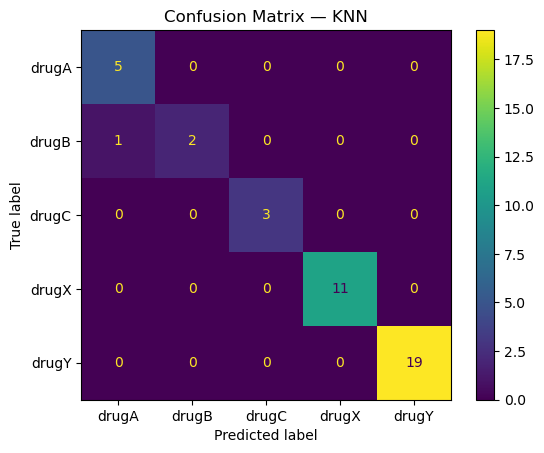

In [20]:
knn_final = Pipeline(steps=[
    ("pre", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=best_k, weights="distance"))
])
knn_final.fit(X_train, y_train)
pred = knn_final.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy KNN final:", acc)
print(classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred, labels=list(le.classes_))
disp = ConfusionMatrixDisplay(cm, display_labels=list(le.classes_))
disp.plot(values_format="d")
plt.title("Confusion Matrix — KNN")
plt.show()


## Ejercicio 6 (1 punto): Comparación (markdown)

**Qué comparar:**
- Accuracy
- Matriz de confusión (en qué clases se equivoca)
- Coste de inferencia

Pista rápida:
- **KNN**: no “entrena” mucho, pero predecir es caro (depende de todo el dataset).
- **MLPClassifier**: entrena más, pero predecir es muy rápido (solo multiplicaciones de matrices).


## Ejercicio 7 (1 punto): Binaria softDrug vs hardDrug con MLP propio

Transformación pedida:
- `drugA`, `drugB`, `drugC`  -> `softDrug`
- `drugX`, `drugY`          -> `hardDrug`

Entrenamos un MLP binario (sigmoid + BCE) y buscamos un rendimiento similar o mejor que en el Ej. 3.


In [21]:
df_bin = df.copy()
df_bin["DrugBin"] = df_bin["Drug"].replace({
    "drugA": "softDrug",
    "drugB": "softDrug",
    "drugC": "softDrug",
    "drugX": "hardDrug",
    "drugY": "hardDrug",
})

Xb = df_bin.drop(columns=["Drug", "DrugBin"])
yb = (df_bin["DrugBin"] == "hardDrug").astype(int)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=13, stratify=yb
)

Xb_train_t = preprocess.fit_transform(Xb_train)
Xb_test_t  = preprocess.transform(Xb_test)

print("Positivos (hardDrug) en train:", yb_train.mean())
print("Xb_train_t:", Xb_train_t.shape)


Positivos (hardDrug) en train: 0.725
Xb_train_t: (160, 9)


In [22]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

class NumpyMLPBinary:
    """MLP binario (NumPy): ocultas ReLU, salida sigmoid."""
    def __init__(self, layer_sizes, seed=13, l2=1e-4):
        self.sizes = list(layer_sizes)
        self.rng = np.random.default_rng(seed)
        self.l2 = float(l2)

        self.W, self.b = [], []
        for i in range(len(self.sizes)-1):
            fan_in, fan_out = self.sizes[i], self.sizes[i+1]
            scale = np.sqrt(2.0 / fan_in) if i < len(self.sizes)-2 else np.sqrt(1.0 / fan_in)
            self.W.append(self.rng.normal(0, scale, size=(fan_in, fan_out)).astype(np.float32))
            self.b.append(np.zeros((1, fan_out), dtype=np.float32))

    def forward(self, X):
        a = X.astype(np.float32)
        activations, zs = [a], []
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            zs.append(z)
            if i == len(self.W)-1:
                a = sigmoid(z)
            else:
                a = np.maximum(0, z)  # ReLU
            activations.append(a)
        return activations, zs

    def predict_proba(self, X):
        a = X.astype(np.float32)
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            if i == len(self.W)-1:
                a = sigmoid(z)
            else:
                a = np.maximum(0, z)
        return a.ravel()

    def predict(self, X, thresh=0.5):
        return (self.predict_proba(X) >= thresh).astype(int)

    def fit(self, X, y, epochs=800, lr=0.05, batch_size=32, verbose_every=0):
        X = X.astype(np.float32)
        y = y.astype(np.float32).reshape(-1, 1)
        n = X.shape[0]

        for ep in range(epochs):
            idx = self.rng.permutation(n)
            Xs, Ys = X[idx], y[idx]

            for start in range(0, n, batch_size):
                xb = Xs[start:start+batch_size]
                yb = Ys[start:start+batch_size]

                activations, zs = self.forward(xb)
                out = activations[-1]

                # sigmoid + BCE => delta = out - y
                delta = (out - yb) / xb.shape[0]

                dW = [None]*len(self.W)
                db = [None]*len(self.b)

                for i in reversed(range(len(self.W))):
                    a_prev = activations[i]
                    dW[i] = a_prev.T @ delta + self.l2 * self.W[i]
                    db[i] = np.sum(delta, axis=0, keepdims=True)

                    if i > 0:
                        delta = (delta @ self.W[i].T) * (zs[i-1] > 0).astype(np.float32)

                for i in range(len(self.W)):
                    self.W[i] -= lr * dW[i]
                    self.b[i] -= lr * db[i]

            if verbose_every and (ep % verbose_every == 0 or ep == epochs-1):
                acc = (self.predict(X) == y.ravel()).mean()
                print(f"Epoch {ep:4d} | train acc = {acc:.3f}")

        return self


Accuracy binario (1 hidden): 1.0


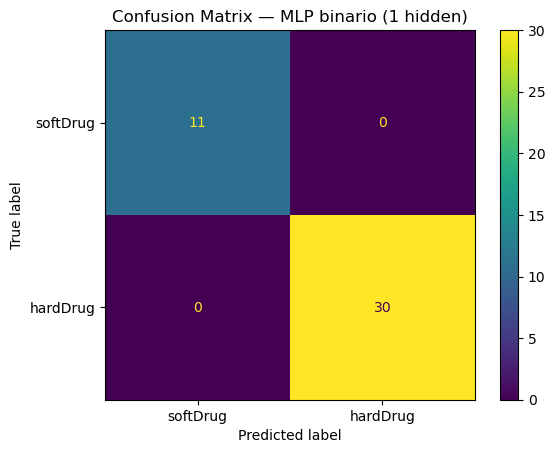

In [23]:
mlp_bin_1h = NumpyMLPBinary(
    layer_sizes=[Xb_train_t.shape[1], 16, 1],
    seed=13,
    l2=1e-4
)
mlp_bin_1h.fit(Xb_train_t, yb_train.to_numpy(), epochs=800, lr=0.05, batch_size=32)

pred = mlp_bin_1h.predict(Xb_test_t)
acc = accuracy_score(yb_test, pred)
print("Accuracy binario (1 hidden):", acc)

cm = confusion_matrix(yb_test, pred, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=["softDrug", "hardDrug"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — MLP binario (1 hidden)")
plt.show()


### (Requisito de “>1 capa oculta”) en binario

Aunque aquí no sea obligatorio explícitamente, es buena práctica mostrar una prueba con 2 ocultas también.


Accuracy binario (2 hidden): 1.0


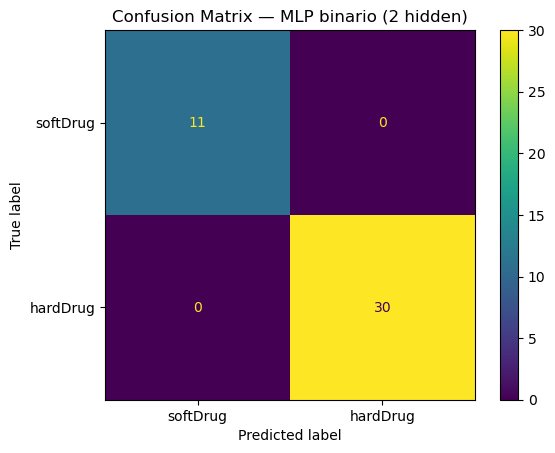

MODELO FINAL (binario): mlp_bin_2h


In [24]:
mlp_bin_2h = NumpyMLPBinary(
    layer_sizes=[Xb_train_t.shape[1], 16, 8, 1],
    seed=13,
    l2=1e-4
)
mlp_bin_2h.fit(Xb_train_t, yb_train.to_numpy(), epochs=800, lr=0.05, batch_size=32)

pred2 = mlp_bin_2h.predict(Xb_test_t)
acc2 = accuracy_score(yb_test, pred2)
print("Accuracy binario (2 hidden):", acc2)

cm2 = confusion_matrix(yb_test, pred2, labels=[0,1])
disp2 = ConfusionMatrixDisplay(cm2, display_labels=["softDrug", "hardDrug"])
disp2.plot(values_format="d")
plt.title("Confusion Matrix — MLP binario (2 hidden)")
plt.show()

print("MODELO FINAL (binario):", "mlp_bin_2h" if acc2 >= acc else "mlp_bin_1h")


## Checklist de examen (limpieza “no al tuntún”)

- `df.info()` + `df.isna().sum()` siempre.
- Normaliza strings (`strip`, mayúsculas/minúsculas) **antes** de one-hot.
- Decide imputación:
  - numéricas → mediana,
  - categóricas → moda.
- Divide con `random_state` pedido.
- Evalúa con accuracy + matriz de confusión y explica errores.

Fin.
